# QFlow Lite — Quantum Dot Device State Classification
**Dataset:** 1 001 simulated 100×100 stability maps  
**Task:** 4-class classification — Barrier | Single Dot | Double Dot | Short Circuit  
**Models:** SVM · Random Forest · Gradient Boosting · MLP (2-layer) · MLP (4-layer) · CNN (PyTorch, optional)


## 0 · Install / verify dependencies

In [ ]:
# Run once if needed — comment out after first run
# !pip install scikit-learn matplotlib numpy tqdm
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu


## 1 · Imports & configuration

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets          # progress bars without tqdm dependency

# ── scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# ── PyTorch (optional) ────────────────────────────────────────────────────────
try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    print(f"PyTorch {torch.__version__} found  |  device: "
          f"{'cuda' if torch.cuda.is_available() else 'cpu'}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not found — CNN cell will be skipped.")

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11,
                     "axes.labelsize": 10, "font.family": "DejaVu Sans"})
print("✓ Imports complete")


C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


PyTorch 2.1.2+cpu found  |  device: cpu
✓ Imports complete


## 2 · Configuration — edit paths here

In [2]:
# ── EDIT THESE IF NEEDED ─────────────────────────────────────────────────────
DATA_DIR       = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")
OUT_DIR        = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite/results")

RANDOM_STATE   = 42
TEST_SIZE      = 0.20     # 80/20 split
N_PCA          = 128      # PCA components per channel (reduce to 64 if slow)
CNN_EPOCHS     = 30
CNN_BATCH      = 32
# ─────────────────────────────────────────────────────────────────────────────

LABEL_NAMES = {0: "Barrier", 1: "Single Dot", 2: "Double Dot", 3: "Short Circuit"}
COLORS      = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d"]

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data dir  : {DATA_DIR}")
print(f"Output dir: {OUT_DIR}")


Data dir  : C:\Users\Lehma\AIProjects\data_qflow_lite
Output dir: C:\Users\Lehma\AIProjects\data_qflow_lite\results


## 3 · Load dataset

In [4]:
import numpy as np
import os
from pathlib import Path

DATA_DIR = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")

def load_dataset(data_dir):
    files = sorted([f for f in os.listdir(data_dir)
                    if f.endswith('.npy') and not f.startswith('.')])

    currents, coulombs, occupancies, labels = [], [], [], []
    skipped = 0

    for fname in files:
        try:
            data = np.load(data_dir / fname, allow_pickle=True).item()
            output = data['output']   # list of 10000 dicts (one per pixel)

            if len(output) != 10000:
                skipped += 1
                continue

            # ── Current map (100×100) ────────────────────────────────────────
            current_map = np.array([p['current'] for p in output],
                                   dtype=np.float32).reshape(100, 100)

            # ── Coulomb / sensor map — first sensor value ────────────────────
            sensor_map  = np.array([p['sensor'][0] if hasattr(p['sensor'], '__len__')
                                    else float(p['sensor'])
                                    for p in output],
                                   dtype=np.float32).reshape(100, 100)

            # ── Charge occupancy map — encode as number of charges ───────────
            def charge_to_float(c):
                try:
                    return float(len(c)) if hasattr(c, '__len__') else float(c)
                except Exception:
                    return 0.0

            charge_map = np.array([charge_to_float(p['charge']) for p in output],
                                  dtype=np.float32).reshape(100, 100)

            # ── Label: majority device state across all pixels ───────────────
            states = [p['state'] for p in output]
            label  = int(max(set(states), key=states.count))

            currents.append(current_map)
            coulombs.append(sensor_map)
            occupancies.append(charge_map)
            labels.append(label)

        except Exception as e:
            print(f"  WARN {fname}: {e}")
            skipped += 1

    if skipped:
        print(f"Skipped {skipped} files.")

    current   = np.stack(currents)
    coulomb   = np.stack(coulombs)
    occupancy = np.stack(occupancies)
    labels    = np.array(labels, dtype=np.int64)

    print(f"\nLoaded {len(labels)} samples")
    print(f"Map shape per sample: {current[0].shape}")
    print("\nClass distribution:")
    for k, name in LABEL_NAMES.items():
        n = (labels == k).sum()
        bar = "█" * int(n / len(labels) * 40)
        print(f"  {name:<14} ({k})  {n:>4} samples  {bar}")

    return current, coulomb, occupancy, labels


current, coulomb, occupancy, labels = load_dataset(DATA_DIR)



Loaded 1001 samples
Map shape per sample: (100, 100)

Class distribution:
  Barrier        (0)    18 samples  
  Single Dot     (1)   756 samples  ██████████████████████████████
  Double Dot     (2)   227 samples  █████████
  Short Circuit  (3)     0 samples  


## 4 · Visualise sample stability maps

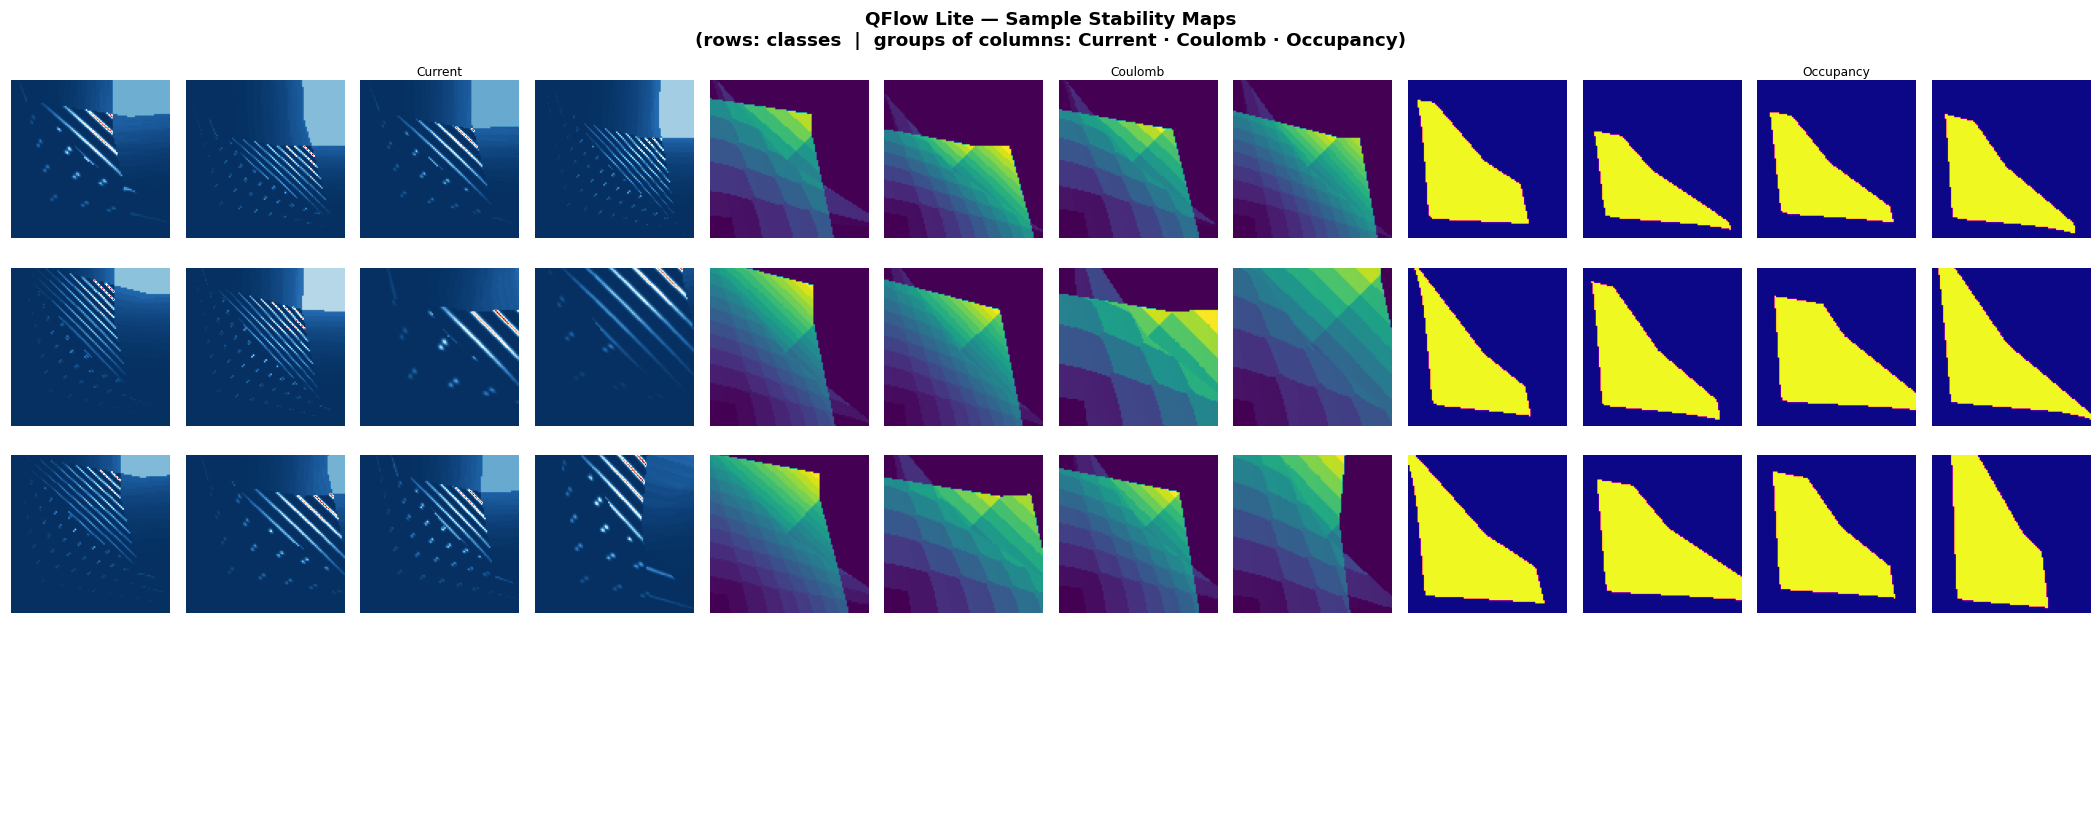

Saved → results/sample_maps.png


In [5]:
def plot_samples(current, coulomb, occupancy, labels, n_per_class=4):
    """Grid: rows = classes, cols = channels × examples."""
    channels   = [("Current",   current,   "RdBu_r"),
                  ("Coulomb",   coulomb,   "viridis"),
                  ("Occupancy", occupancy, "plasma")]
    n_cls      = len(LABEL_NAMES)
    cols_total = len(channels) * n_per_class

    fig, axes = plt.subplots(n_cls, cols_total,
                             figsize=(cols_total * 1.6, n_cls * 1.9),
                             squeeze=False)
    fig.suptitle("QFlow Lite — Sample Stability Maps\n"
                 "(rows: classes  |  groups of columns: Current · Coulomb · Occupancy)",
                 fontsize=12, fontweight="bold")

    for row, (cls_idx, cls_name) in enumerate(LABEL_NAMES.items()):
        sample_idx = np.where(labels == cls_idx)[0][:n_per_class]
        for ch_col, (ch_name, ch_data, cmap) in enumerate(channels):
            for s, idx in enumerate(sample_idx):
                col = ch_col * n_per_class + s
                ax  = axes[row, col]
                ax.imshow(ch_data[idx], cmap=cmap, origin="lower")
                ax.axis("off")
                if s == 0:
                    ax.set_ylabel(cls_name, fontsize=8, rotation=90, labelpad=4)
                if row == 0 and s == n_per_class // 2:
                    ax.set_title(ch_name, fontsize=8, pad=3)
            # fill empty columns
            for s in range(len(sample_idx), n_per_class):
                axes[row, ch_col * n_per_class + s].axis("off")

    plt.tight_layout()
    fig.savefig(OUT_DIR / "sample_maps.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → results/sample_maps.png")

plot_samples(current, coulomb, occupancy, labels)


## 5 · Feature engineering
Each of the 3 channels contributes **14 statistical descriptors** + **128 PCA components** → 426-dim flat vector fed to classical models.

In [6]:
def channel_stats(maps):
    """14 descriptors per sample: mean, std, min, max, skewness, 9 percentiles."""
    N    = len(maps)
    flat = maps.reshape(N, -1)
    p    = np.percentile(flat, [10,20,30,40,50,60,70,80,90], axis=1).T
    mu   = flat.mean(1, keepdims=True)
    sg   = flat.std(1,  keepdims=True)
    skew = ((flat - mu)**3).mean(1, keepdims=True) / (sg**3 + 1e-8)
    return np.hstack([mu, sg, flat.min(1,keepdims=True),
                      flat.max(1,keepdims=True), skew, p])   # (N,14)


def build_flat_features(current, coulomb, occupancy, n_pca=N_PCA):
    """Return (N, 42 + 3*n_pca) feature matrix."""
    N     = len(current)
    stats = np.hstack([channel_stats(current),
                       channel_stats(coulomb),
                       channel_stats(occupancy)])   # (N, 42)

    pca_parts = []
    for ch, name in zip([current, coulomb, occupancy],
                        ["current", "coulomb", "occupancy"]):
        flat   = ch.reshape(N, -1)
        flat_s = StandardScaler().fit_transform(flat)
        k      = min(n_pca, flat_s.shape[1], N - 1)
        pca_parts.append(PCA(k, random_state=RANDOM_STATE).fit_transform(flat_s))
        print(f"  PCA({name}): {k} components")

    return np.hstack([stats] + pca_parts)


def build_2d_features(current, coulomb, occupancy):
    """Stack channels → (N, 3, 100, 100) for CNN."""
    return np.stack([current, coulomb, occupancy], axis=1)


print("Building flat features …")
X_flat = build_flat_features(current, coulomb, occupancy)
X_2d   = build_2d_features(current, coulomb, occupancy)
print(f"\nFlat feature matrix : {X_flat.shape}")
print(f"2D tensor           : {X_2d.shape}")


Building flat features …
  PCA(current): 128 components
  PCA(coulomb): 128 components
  PCA(occupancy): 128 components

Flat feature matrix : (1001, 426)
2D tensor           : (1001, 3, 100, 100)


## 6 · PCA scatter — are classes separable?

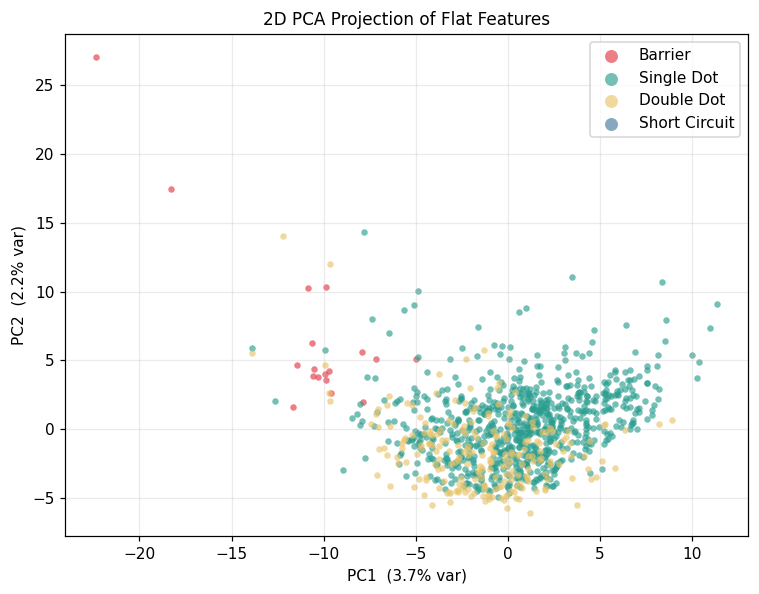

In [7]:
pca2   = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca2.fit_transform(StandardScaler().fit_transform(X_flat))

fig, ax = plt.subplots(figsize=(7, 5.5))
for k, name in LABEL_NAMES.items():
    mask = labels == k
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=COLORS[k], label=name, alpha=0.65, s=18, linewidths=0)

ax.set_xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("2D PCA Projection of Flat Features")
ax.legend(markerscale=2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 7 · Train / test split

In [8]:
(X_tr, X_te,
 y_tr, y_te,
 idx_tr, idx_te) = train_test_split(
    X_flat, labels, np.arange(len(labels)),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels
)

X_2d_tr = X_2d[idx_tr]
X_2d_te = X_2d[idx_te]

print(f"Train : {len(y_tr)} samples")
print(f"Test  : {len(y_te)} samples")
print(f"\nClass balance in test set:")
for k, name in LABEL_NAMES.items():
    print(f"  {name:<14}  {(y_te==k).sum()}")


Train : 800 samples
Test  : 201 samples

Class balance in test set:
  Barrier         4
  Single Dot      152
  Double Dot      45
  Short Circuit   0


## 8 · Classical models
SVM · Random Forest · Gradient Boosting · MLP (2-layer) · MLP (4-layer)

In [9]:
MODELS = {
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10, gamma="scale",
                    class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=500, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=RANDOM_STATE))
    ]),
    "MLP (2-layer)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(512, 256), activation="relu",
            max_iter=300, early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE))
    ]),
    "MLP (4-layer)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(1024, 512, 256, 128), activation="relu",
            learning_rate_init=5e-4,
            max_iter=300, early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE))
    ]),
}

CLASS_NAMES = [LABEL_NAMES[k] for k in sorted(LABEL_NAMES)]
ALL_LABELS  = sorted(LABEL_NAMES.keys())   # [0, 1, 2, 3] — always force all 4
results = []

for name, pipe in MODELS.items():
    print(f"\n{'─'*55}")
    print(f"  Training: {name} …")
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = pipe.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)

    report = classification_report(y_te, y_pred,
                                   labels=ALL_LABELS,
                                   target_names=CLASS_NAMES,
                                   output_dict=True,
                                   zero_division=0)
    cm     = confusion_matrix(y_te, y_pred, labels=ALL_LABELS)

    print(f"  Accuracy : {acc*100:.2f}%  |  Time: {elapsed:.1f}s")
    print(classification_report(y_te, y_pred,
                                labels=ALL_LABELS,
                                target_names=CLASS_NAMES,
                                zero_division=0))

    results.append({"name": name, "acc": acc, "report": report,
                    "cm": cm, "y_pred": y_pred, "train_time": elapsed})

print("\n✓ All classical models done")



───────────────────────────────────────────────────────
  Training: SVM (RBF) …
  Accuracy : 85.07%  |  Time: 0.1s
               precision    recall  f1-score   support

      Barrier       0.00      0.00      0.00         4
   Single Dot       0.85      0.98      0.91       152
   Double Dot       0.88      0.49      0.63        45
Short Circuit       0.00      0.00      0.00         0

     accuracy                           0.85       201
    macro avg       0.43      0.37      0.38       201
 weighted avg       0.84      0.85      0.83       201


───────────────────────────────────────────────────────
  Training: Random Forest …
  Accuracy : 81.59%  |  Time: 1.4s
               precision    recall  f1-score   support

      Barrier       1.00      0.25      0.40         4
   Single Dot       0.80      1.00      0.89       152
   Double Dot       1.00      0.24      0.39        45
Short Circuit       0.00      0.00      0.00         0

     accuracy                           0.82

### 8a · Random Forest feature importance

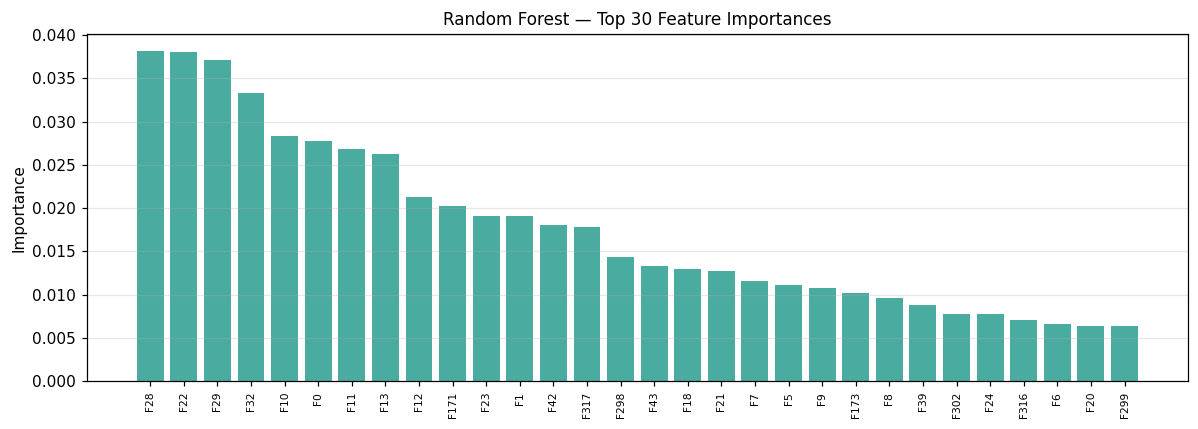

Saved → results/rf_feature_importance.png


In [10]:
rf  = MODELS["Random Forest"].named_steps["clf"]
imp = rf.feature_importances_
top_n  = 30
top_ix = np.argsort(imp)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(top_n), imp[top_ix], color="#2a9d8f", alpha=0.85)
ax.set_xticks(range(top_n))
ax.set_xticklabels([f"F{i}" for i in top_ix], rotation=90, fontsize=7)
ax.set_title(f"Random Forest — Top {top_n} Feature Importances")
ax.set_ylabel("Importance")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "rf_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → results/rf_feature_importance.png")


## 9 · CNN (PyTorch)
4 conv blocks with BatchNorm + Global Average Pooling.  
*Skip this cell if PyTorch is not installed — all classical models above still run.*

In [15]:
if not TORCH_AVAILABLE:
    print("PyTorch not available — skipping CNN.")
else:
    # ── Model definition ──────────────────────────────────────────────────────
    class QuantumDotCNN(nn.Module):
        def __init__(self, n_classes=4):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32,32,3,padding=1),nn.BatchNorm2d(32), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(0.10),            # →32×50×50

                nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(0.15),            # →64×25×25

                nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
                nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
                nn.MaxPool2d(5), nn.Dropout2d(0.20),            # →128×5×5

                nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(),
                nn.AdaptiveAvgPool2d(1),                        # →256×1×1
            )
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(0.4),
                nn.Linear(256,128), nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, n_classes)
            )
        def forward(self, x):
            return self.head(self.features(x))

    # ── Normalise per channel ─────────────────────────────────────────────────
    mu  = X_2d_tr.mean(axis=(0,2,3), keepdims=True)
    sig = X_2d_tr.std(axis=(0,2,3),  keepdims=True) + 1e-8
    Xtr_n = (X_2d_tr - mu) / sig
    Xte_n = (X_2d_te - mu) / sig

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    tr_dl = DataLoader(TensorDataset(torch.tensor(Xtr_n), torch.tensor(y_tr)),
                       batch_size=CNN_BATCH, shuffle=True,  num_workers=0)
    te_dl = DataLoader(TensorDataset(torch.tensor(Xte_n), torch.tensor(y_te)),
                       batch_size=CNN_BATCH, shuffle=False, num_workers=0)

    model     = QuantumDotCNN(n_classes=len(LABEL_NAMES)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CNN_EPOCHS)

    cnn_hist   = {"loss": [], "val_acc": []}
    best_acc   = 0.0
    best_state = None
    t0 = time.time()

    for epoch in range(1, CNN_EPOCHS + 1):
        model.train()
        ep_loss = 0.0
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * len(yb)
        scheduler.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in te_dl:
                preds   = model(Xb.to(device)).argmax(1).cpu()
                correct += (preds == yb).sum().item()
                total   += len(yb)
        val_acc = correct / total

        cnn_hist["loss"].append(ep_loss / len(tr_dl.dataset))
        cnn_hist["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{CNN_EPOCHS}  "
                  f"loss={cnn_hist['loss'][-1]:.4f}  "
                  f"val_acc={val_acc*100:.2f}%")

    cnn_time = time.time() - t0
    print(f"\n  Best val accuracy: {best_acc*100:.2f}%  |  Time: {cnn_time:.1f}s")

    # Final predictions
    model.load_state_dict(best_state)
    model.eval()
    preds_all = []
    with torch.no_grad():
        for Xb, _ in te_dl:
            preds_all.append(model(Xb.to(device)).argmax(1).cpu().numpy())
    y_cnn  = np.concatenate(preds_all)
    acc_cn = accuracy_score(y_te, y_cnn)
    print(classification_report(y_te, y_cnn, labels=ALL_LABELS, target_names=CLASS_NAMES, output_dict=True, zero_division=0))

    results.append({
        "name": "CNN (PyTorch)", "acc": acc_cn,
        "report": classification_report(y_te, y_cnn,labels=ALL_LABELS,target_names=CLASS_NAMES, 
                                        output_dict=True, zero_division=0),
        "cm": confusion_matrix(y_te, y_cnn),
        "y_pred": y_cnn, "train_time": cnn_time, "history": cnn_hist
    })


Using device: cpu
  Epoch   1/30  loss=0.6451  val_acc=76.62%
  Epoch   5/30  loss=0.3698  val_acc=87.56%
  Epoch  10/30  loss=0.2894  val_acc=88.56%
  Epoch  15/30  loss=0.2525  val_acc=91.54%
  Epoch  20/30  loss=0.2294  val_acc=93.53%
  Epoch  25/30  loss=0.1933  val_acc=93.53%
  Epoch  30/30  loss=0.1966  val_acc=93.03%

  Best val accuracy: 95.02%  |  Time: 569.4s
{'Barrier': {'precision': 1.0, 'recall': 0.25, 'f1-score': 0.4, 'support': 4.0}, 'Single Dot': {'precision': 0.9798657718120806, 'recall': 0.9605263157894737, 'f1-score': 0.9700996677740864, 'support': 152.0}, 'Double Dot': {'precision': 0.8627450980392157, 'recall': 0.9777777777777777, 'f1-score': 0.9166666666666666, 'support': 45.0}, 'Short Circuit': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'accuracy': 0.9502487562189055, 'macro avg': {'precision': 0.7106527174628241, 'recall': 0.5470760233918128, 'f1-score': 0.5716915836101882, 'support': 201.0}, 'weighted avg': {'precision': 0.9540454066029

In [21]:
results

[{'name': 'SVM (RBF)',
  'acc': 0.8507462686567164,
  'report': {'Barrier': {'precision': 0.0,
    'recall': 0.0,
    'f1-score': 0.0,
    'support': 4.0},
   'Single Dot': {'precision': 0.8465909090909091,
    'recall': 0.9802631578947368,
    'f1-score': 0.9085365853658537,
    'support': 152.0},
   'Double Dot': {'precision': 0.88,
    'recall': 0.4888888888888889,
    'f1-score': 0.6285714285714286,
    'support': 45.0},
   'Short Circuit': {'precision': 0.0,
    'recall': 0.0,
    'f1-score': 0.0,
    'support': 0.0},
   'accuracy': 0.8507462686567164,
   'macro avg': {'precision': 0.43164772727272727,
    'recall': 0.3672880116959064,
    'f1-score': 0.3842770034843206,
    'support': 201.0},
   'weighted avg': {'precision': 0.8372229760289461,
    'recall': 0.8507462686567164,
    'f1-score': 0.8277774888623086,
    'support': 201.0}},
  'cm': array([[  0,   4,   0,   0],
         [  0, 149,   3,   0],
         [  0,  23,  22,   0],
         [  0,   0,   0,   0]], dtype=int64),


### 9a · CNN training curves

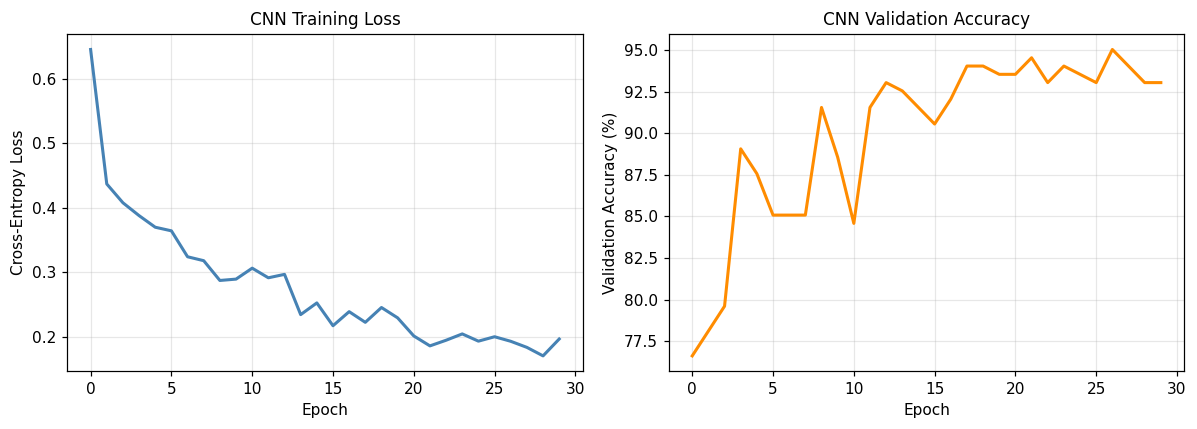

In [16]:
if TORCH_AVAILABLE and "history" in results[-1]:
    h   = results[-1]["history"]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

    a1.plot(h["loss"], color="steelblue", lw=2)
    a1.set_xlabel("Epoch"); a1.set_ylabel("Cross-Entropy Loss")
    a1.set_title("CNN Training Loss"); a1.grid(alpha=0.3)

    a2.plot(np.array(h["val_acc"]) * 100, color="darkorange", lw=2)
    a2.set_xlabel("Epoch"); a2.set_ylabel("Validation Accuracy (%)")
    a2.set_title("CNN Validation Accuracy"); a2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## 10 · Confusion matrices (all models)

ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

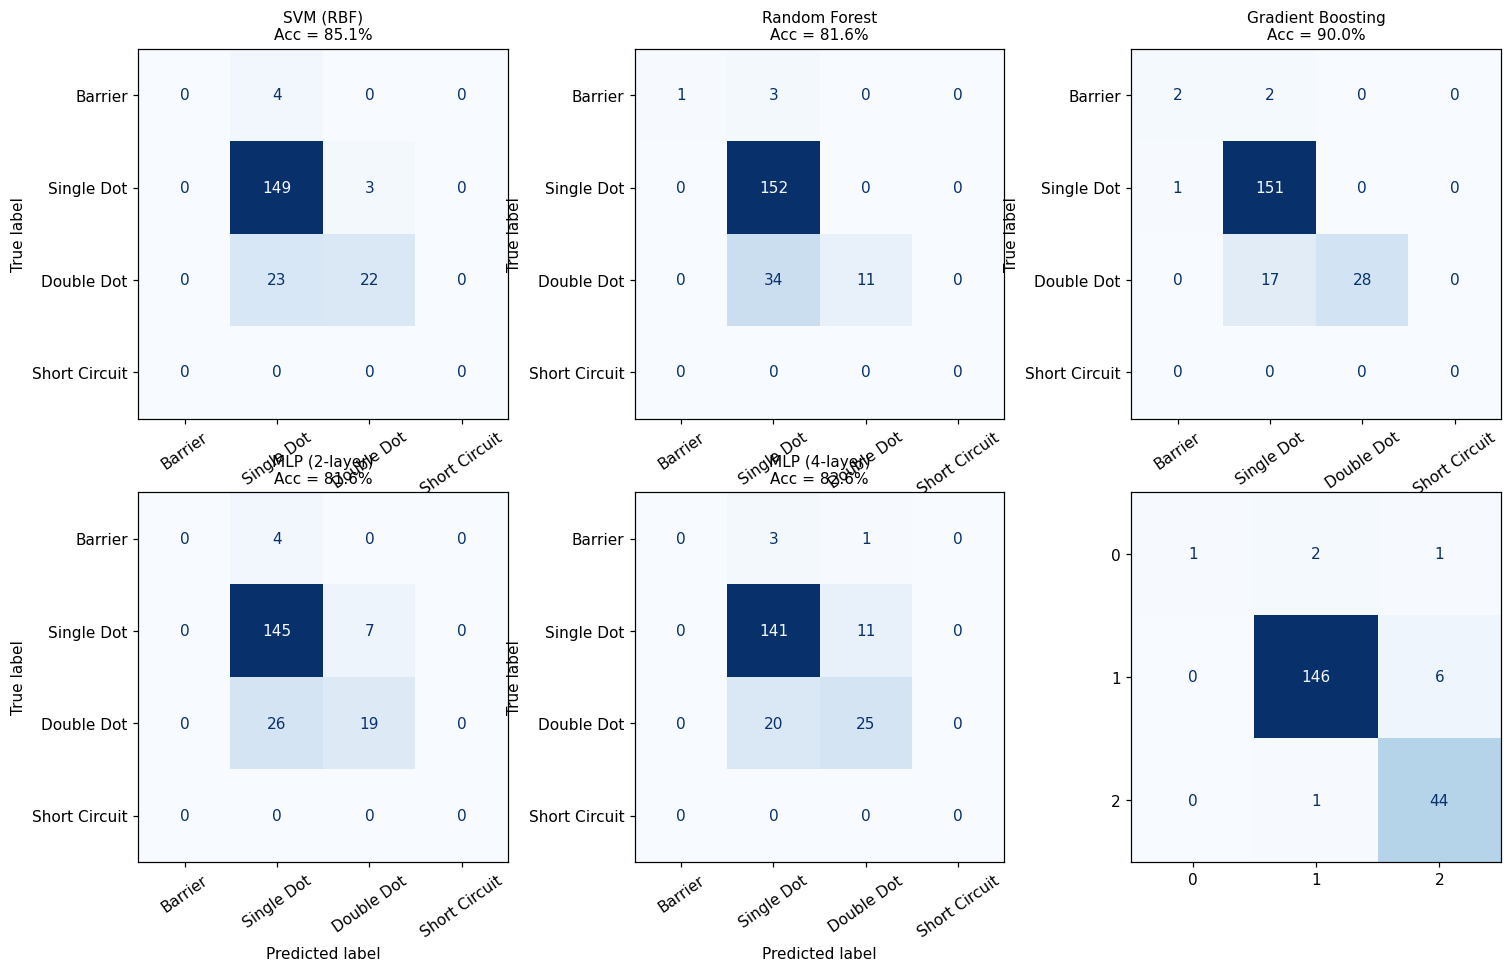

In [25]:
n    = len(results)
cols = min(3, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols,
                         figsize=(5.5 * cols, 4.8 * rows), squeeze=False)
axes_flat = axes.flatten()

for ax, res in zip(axes_flat, results):
    disp = ConfusionMatrixDisplay(res["cm"], display_labels=['Barrier','Single Dot','Double Dot','Short Circuit'])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=35)
    ax.set_title(f"{res['name']}\nAcc = {res['acc']*100:.1f}%", fontsize=10)

for ax in axes_flat[len(results):]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


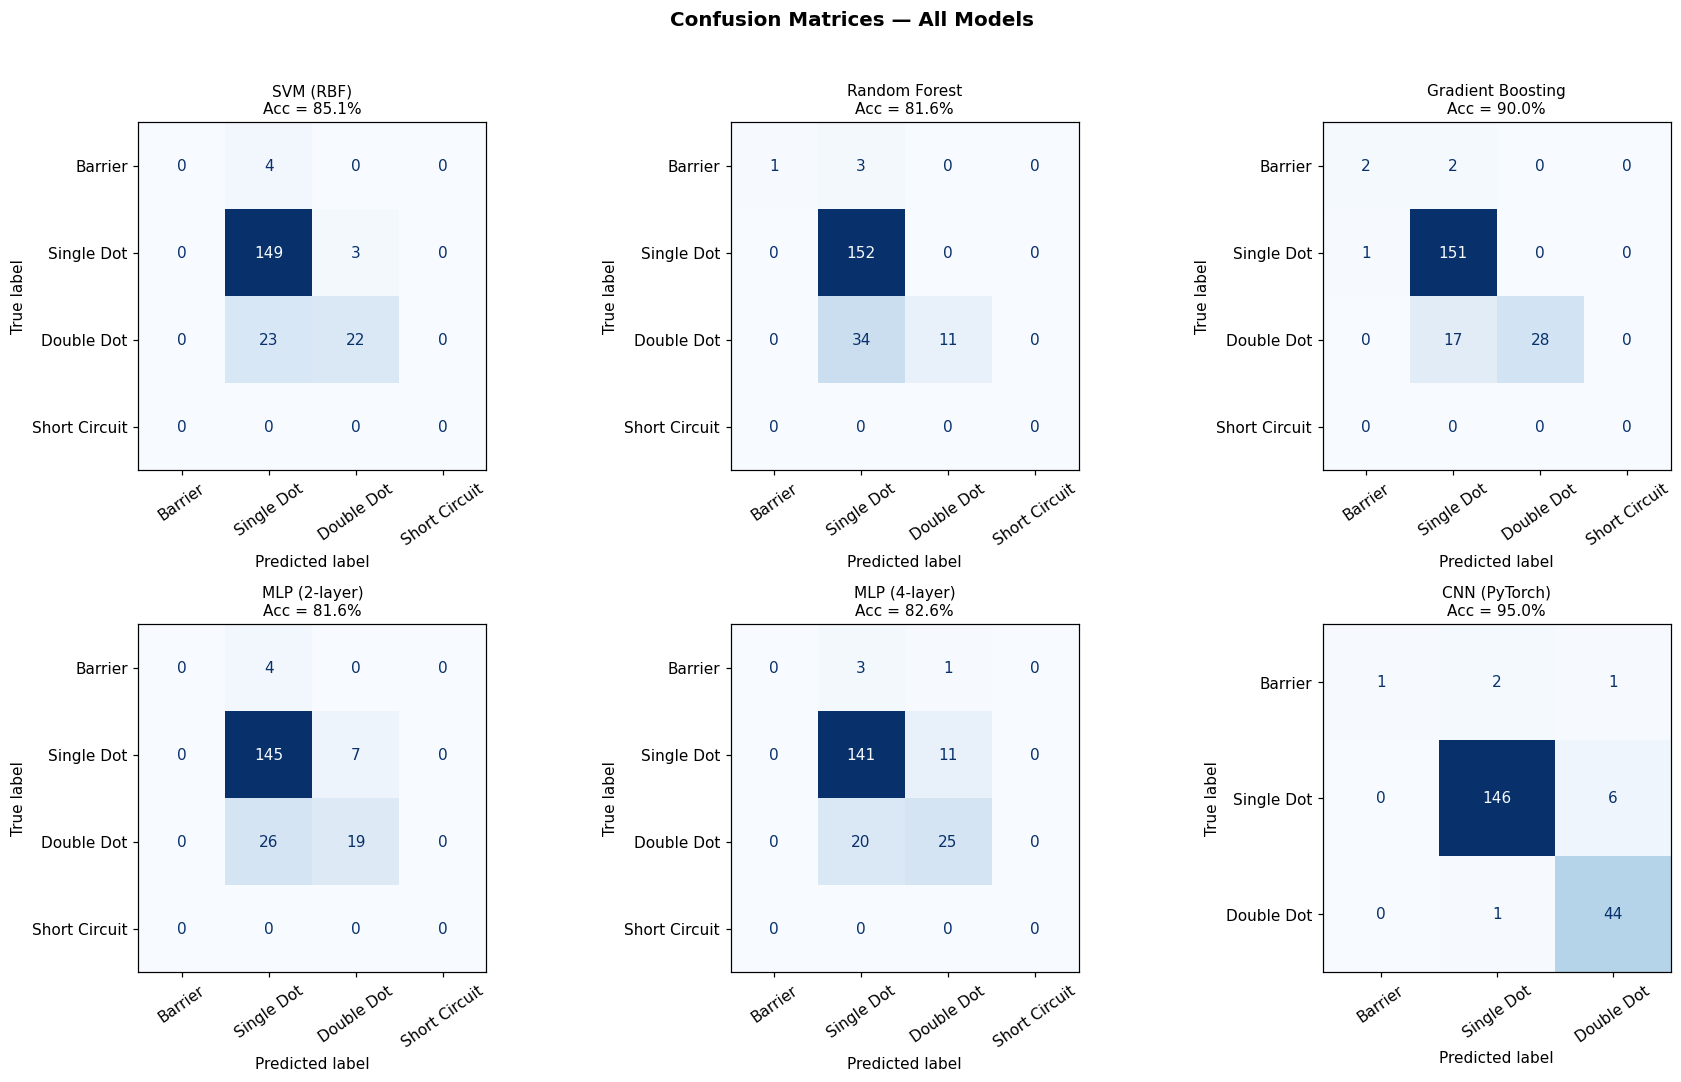

In [27]:
#Fixed the Graphing
n = len(results)
cols = min(3, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(
    rows, cols,
    figsize=(5.5 * cols, 4.8 * rows),
    squeeze=False
)

axes_flat = axes.flatten()

for ax, res in zip(axes_flat, results):
    cm = res["cm"]
    
    # Match labels to matrix size
    num_classes = cm.shape[0]
    labels = CLASS_NAMES[:num_classes]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    
    disp.plot(
        ax=ax,
        colorbar=False,
        cmap="Blues",
        xticks_rotation=35
    )
    
    ax.set_title(
        f"{res['name']}\nAcc = {res['acc']*100:.1f}%",
        fontsize=10
    )

# Hide unused subplots
for ax in axes_flat[len(results):]:
    ax.set_visible(False)

plt.suptitle(
    "Confusion Matrices — All Models",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## 11 · Model comparison

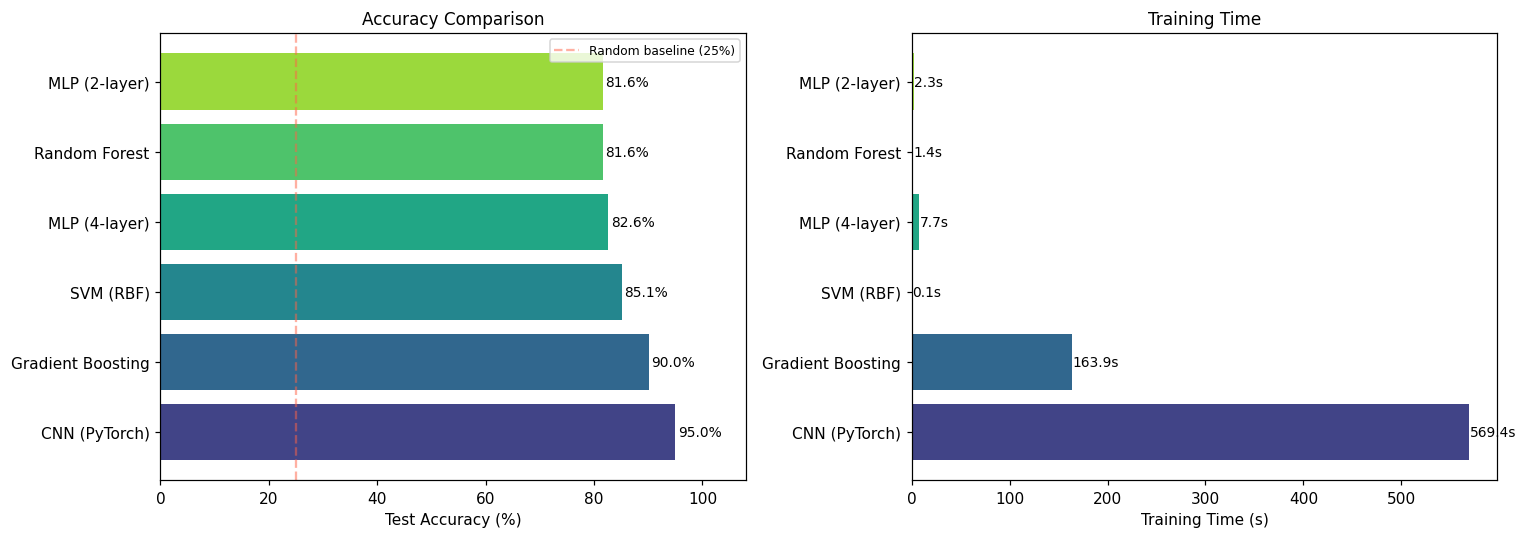

In [28]:
sorted_res = sorted(results, key=lambda r: r["acc"], reverse=True)
names  = [r["name"]       for r in sorted_res]
accs   = [r["acc"] * 100  for r in sorted_res]
times  = [r["train_time"] for r in sorted_res]

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(names)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.barh(names, accs, color=colors)
ax1.set_xlabel("Test Accuracy (%)"); ax1.set_xlim(0, 108)
ax1.set_title("Accuracy Comparison")
ax1.axvline(25, color="tomato", ls="--", alpha=0.5, label="Random baseline (25%)")
ax1.legend(fontsize=8)
for b, v in zip(bars1, accs):
    ax1.text(v + 0.5, b.get_y() + b.get_height()/2,
             f"{v:.1f}%", va="center", fontsize=9)

bars2 = ax2.barh(names, times, color=colors)
ax2.set_xlabel("Training Time (s)")
ax2.set_title("Training Time")
for b, v in zip(bars2, times):
    ax2.text(v + 0.2, b.get_y() + b.get_height()/2,
             f"{v:.1f}s", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 12 · Per-class F1-score heatmap

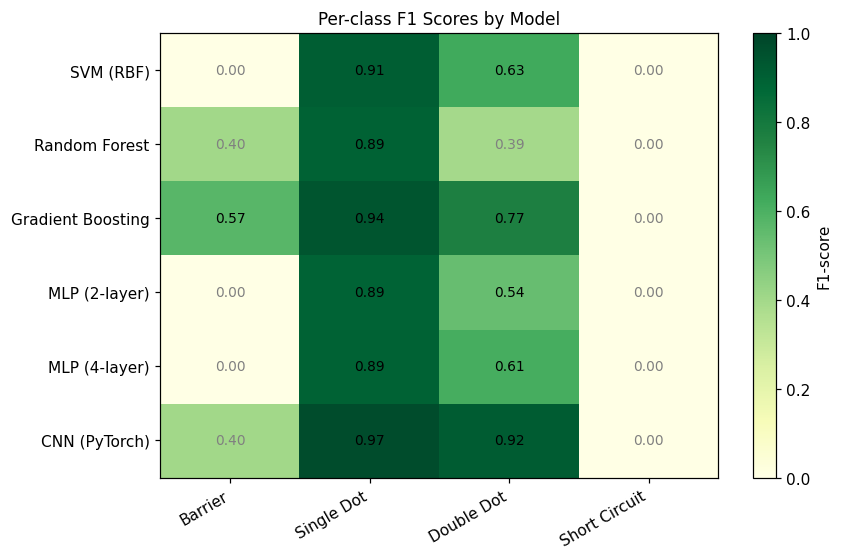

In [29]:
model_names = [r["name"] for r in results]
f1_matrix   = np.array([
    [r["report"].get(cls, {}).get("f1-score", 0) for cls in CLASS_NAMES]
    for r in results
])

fig, ax = plt.subplots(figsize=(8, max(3, len(results) * 0.7 + 1)))
im = ax.imshow(f1_matrix, vmin=0, vmax=1, cmap="YlGn", aspect="auto")
plt.colorbar(im, ax=ax, label="F1-score")

ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names)
ax.set_title("Per-class F1 Scores by Model")

for i in range(len(model_names)):
    for j in range(len(CLASS_NAMES)):
        val = f1_matrix[i, j]
        ax.text(j, i, f"{val:.2f}",
                ha="center", va="center", fontsize=9,
                color="black" if val > 0.5 else "gray")

plt.tight_layout()
plt.show()



## 13 · Final leaderboard & per-class summary

In [30]:
print("\n" + "="*65)
print(f"  {'Model':<22}  {'Accuracy':>9}  {'Time':>8}  {'Macro-F1':>9}")
print("  " + "-"*55)
for r in sorted(results, key=lambda x: -x["acc"]):
    mf1 = r["report"].get("macro avg", {}).get("f1-score", 0)
    print(f"  {r['name']:<22}  {r['acc']*100:>8.2f}%"
          f"  {r['train_time']:>7.1f}s  {mf1:>9.3f}")
print("="*65)

# Save text summary
lines = ["QFlow Lite — Classification Summary", "="*65, ""]
for r in sorted(results, key=lambda x: -x["acc"]):
    lines += [f"Model      : {r['name']}",
              f"Accuracy   : {r['acc']*100:.2f}%",
              f"Train time : {r['train_time']:.1f}s"]
    for cls in CLASS_NAMES:
        d = r["report"].get(cls, {})
        lines.append(f"  {cls:<14} | "
                     f"P={d.get('precision',0):.2f}  "
                     f"R={d.get('recall',0):.2f}  "
                     f"F1={d.get('f1-score',0):.2f}")
    lines.append("")

#(OUT_DIR / "summary.txt").write_text("\n".join(lines))
#print(f"\nFull summary saved → {OUT_DIR / 'summary.txt'}")
#print(f"All plots saved  → {OUT_DIR}")



  Model                    Accuracy      Time   Macro-F1
  -------------------------------------------------------
  CNN (PyTorch)              95.02%    569.4s      0.572
  Gradient Boosting          90.05%    163.9s      0.569
  SVM (RBF)                  85.07%      0.1s      0.384
  MLP (4-layer)              82.59%      7.7s      0.376
  Random Forest              81.59%      1.4s      0.421
  MLP (2-layer)              81.59%      2.3s      0.356
